
Affinity rules, scaled from 3000 RPM
  RPM  Q [l/min]  H meas [m]  H calc [m]  dev [%]
 2000        1.7        5.00        4.86      2.8
 2000       28.0        3.90        3.73      4.7
 2000       32.6        3.70        3.52      5.0
 1000        6.9        1.20        1.09     10.5
 1000        8.1        1.20        1.06     13.2
 1000       10.2        1.10        1.01      8.4


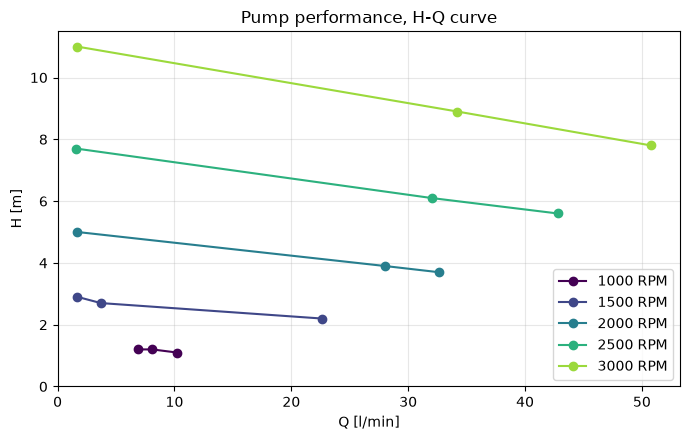

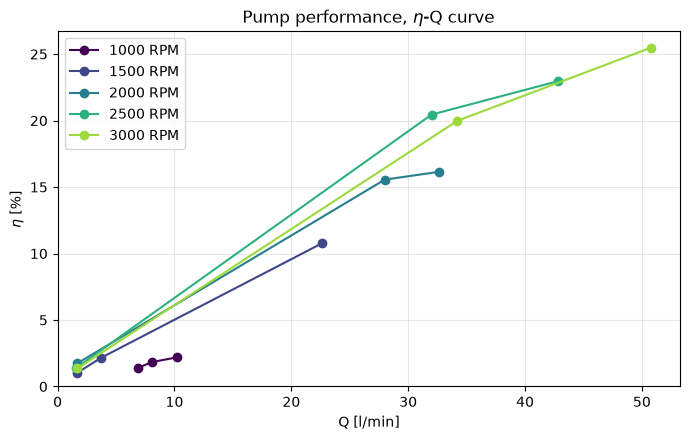

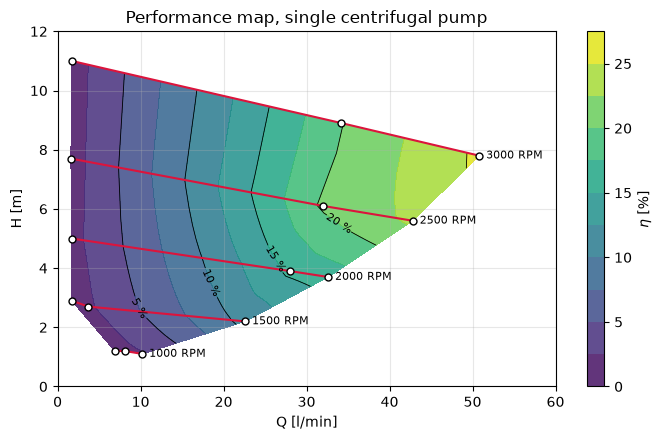

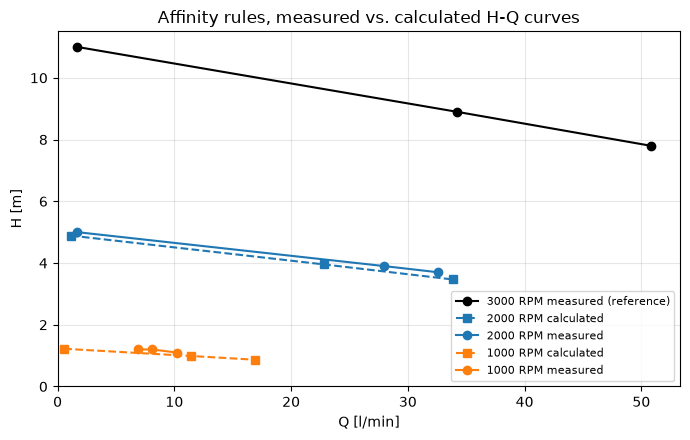

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Raw data from the panel: Q [l/min] (SC-1), Ht [m], eta [%]
data = {
    1000: {"Q": [10.2, 8.1, 6.9], "H": [1.1, 1.2, 1.2], "eta": [2.19, 1.84, 1.41]},
    1500: {"Q": [22.6, 3.7, 1.7], "H": [2.2, 2.7, 2.9], "eta": [10.76, 2.15, 1.04]},
    2000: {"Q": [32.6, 28.0, 1.7], "H": [3.7, 3.9, 5.0], "eta": [16.14, 15.56, 1.75]},
    2500: {"Q": [42.8, 32.0, 1.6], "H": [5.6, 6.1, 7.7], "eta": [22.96, 20.45, 1.40]},
    3000: {"Q": [50.8, 34.2, 1.7], "H": [7.8, 8.9, 11.0], "eta": [25.49, 19.98, 1.36]},
}

colors = plt.cm.viridis(np.linspace(0, 0.85, len(data)))

# Save figures next to the script, or in the current folder in Jupyter
try:
    output_dir = Path(__file__).parent / "figures"
except NameError:
    output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)


def sorted_curve(d, key):
    """Return Q and the chosen quantity sorted by increasing flow."""
    order = np.argsort(d["Q"])
    return np.array(d["Q"])[order], np.array(d[key])[order]


def plot_curve(key, ylabel, title, fname):
    """Task 1: plot H-Q or eta-Q curves for all speeds."""
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for c, (rpm, d) in zip(colors, data.items()):
        Q, y = sorted_curve(d, key)
        ax.plot(Q, y, "o-", color=c, lw=1.5, label=f"{rpm} RPM")
    ax.set_xlabel("Q [l/min]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"{fname}.pdf")


def plot_performance_map(fname):
    s = np.linspace(0, 1, 30)
    Q_grid, H_grid, eta_grid = [], [], []
    for rpm in sorted(data):
        Q, H = sorted_curve(data[rpm], "H")
        _, eta = sorted_curve(data[rpm], "eta")
        t = (Q - Q[0]) / (Q[-1] - Q[0])
        Q_grid.append(np.interp(s, t, Q))
        H_grid.append(np.interp(s, t, H))
        eta_grid.append(np.interp(s, t, eta))
    Q_grid, H_grid, eta_grid = map(np.array, (Q_grid, H_grid, eta_grid))

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Filled iso-efficiency areas + labelled contour lines
    levels = np.arange(0, 28, 2.5)
    cf = ax.contourf(Q_grid, H_grid, eta_grid, levels=levels, cmap="viridis", alpha=0.85)
    cl = ax.contour(Q_grid, H_grid, eta_grid, levels=levels[::2], colors="k", linewidths=0.6)
    ax.clabel(cl, fmt="%.0f %%", fontsize=8)
    fig.colorbar(cf, ax=ax, label=r"$\eta$ [%]")

    # Measured H-Q curve for each speed on top
    for rpm, d in data.items():
        q, h = sorted_curve(d, "H")
        ax.plot(q, h, "o-", color="crimson", mfc="w", mec="k", lw=1.5, ms=5)
        ax.annotate(f"{rpm} RPM", (q[-1], h[-1]), xytext=(5, 0),
                    textcoords="offset points", fontsize=8, va="center")

    ax.set_xlabel("Q [l/min]")
    ax.set_ylabel("H [m]")
    ax.set_title("Performance map, single centrifugal pump")
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 12)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_dir / f"{fname}.pdf")


def affinity(n_ref, n_targets, fname):
    """Task 2: scale the n_ref curve with the affinity rules and compare
    with the measured curves at the target speeds."""
    Q_ref, H_ref = sorted_curve(data[n_ref], "H")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(Q_ref, H_ref, "o-", color="k", lw=1.5,
            label=f"{n_ref} RPM measured (reference)")

    print(f"\nAffinity rules, scaled from {n_ref} RPM")
    print(f"{'RPM':>5} {'Q [l/min]':>10} {'H meas [m]':>11} "
          f"{'H calc [m]':>11} {'dev [%]':>8}")

    for c, n in zip(["tab:blue", "tab:orange"], n_targets):
        r = n / n_ref
        Q_calc = Q_ref * r          # Q ~ n
        H_calc = H_ref * r**2       # H ~ n^2

        Q_meas, H_meas = sorted_curve(data[n], "H")

        ax.plot(Q_calc, H_calc, "s--", color=c, lw=1.5, label=f"{n} RPM calculated")
        ax.plot(Q_meas, H_meas, "o-", color=c, lw=1.5, label=f"{n} RPM measured")

        # Compare at the measured flows: interpolate the calculated curve
        H_interp = np.interp(Q_meas, Q_calc, H_calc)
        dev = (H_meas - H_interp) / H_interp * 100
        for q, hm, hc, d in zip(Q_meas, H_meas, H_interp, dev):
            print(f"{n:>5} {q:>10.1f} {hm:>11.2f} {hc:>11.2f} {d:>8.1f}")

    ax.set_xlabel("Q [l/min]")
    ax.set_ylabel("H [m]")
    ax.set_title("Affinity rules, measured vs. calculated H-Q curves")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(output_dir / f"{fname}.pdf")


if __name__ == "__main__":
    plot_curve("H", "H [m]", "Pump performance, H-Q curve", "HQ_curve")
    plot_curve("eta", r"$\eta$ [%]", r"Pump performance, $\eta$-Q curve", "etaQ_curve")
    plot_performance_map("performance_map")
    affinity(3000, [2000, 1000], "affinity_HQ")
    plt.show()

SciPy not available: using straight lines between the points.


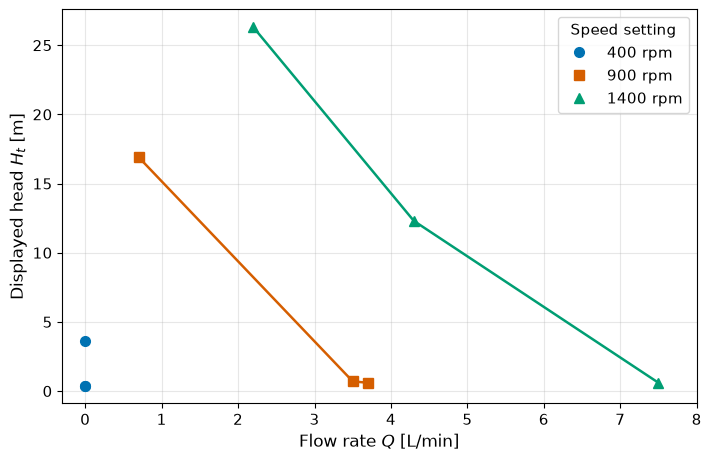

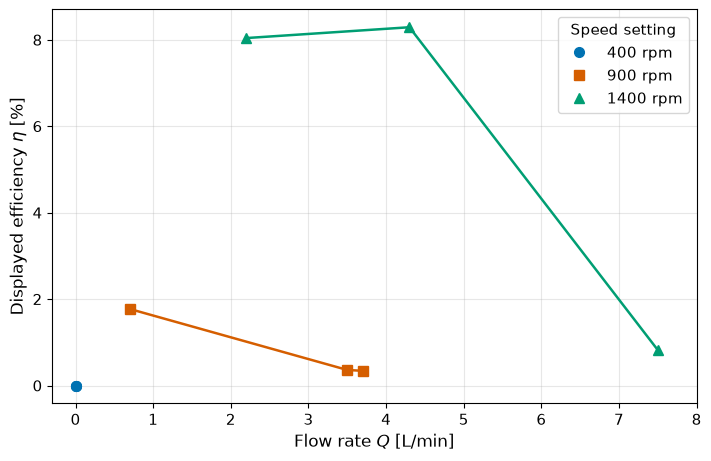

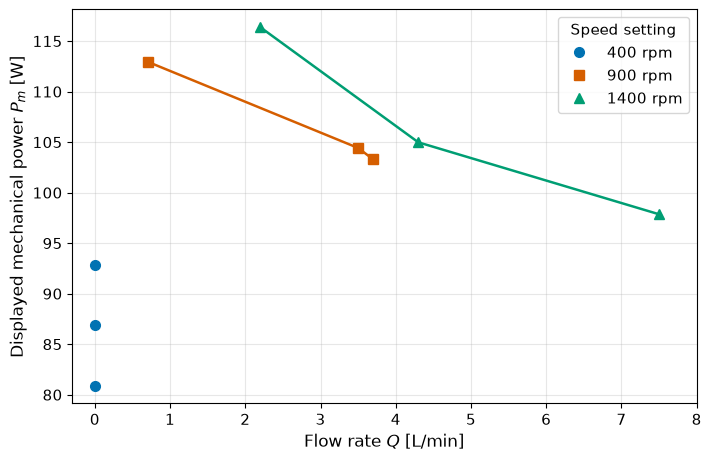

In [3]:
try:
    from scipy.interpolate import PchipInterpolator
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False
    print("SciPy not available: using straight lines between the points.")

# Save figures next to the script, or in the current folder in Jupyter
try:
    output_dir = Path(__file__).parent / "figures"
except NameError:
    output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

# Recorded software values for operating points 1, 2 and 3.
# H is the displayed pump head Ht in metres, not SN-1.
data = {
    400: {
        "Q": [0.0, 0.0, 0.0],
        "H": [0.4, 0.4, 3.6],
        "eta": [0.0, 0.0, 0.0],
        "Pm": [80.91, 86.92, 92.86],
    },
    900: {
        "Q": [3.7, 3.5, 0.7],
        "H": [0.6, 0.7, 16.9],
        "eta": [0.34, 0.36, 1.77],
        "Pm": [103.29, 104.42, 112.96],
    },
    1400: {
        "Q": [7.5, 4.3, 2.2],
        "H": [0.6, 12.3, 26.3],
        "eta": [0.82, 8.29, 8.04],
        "Pm": [97.86, 104.98, 116.37],
    },
}

styles = {
    400: {"color": "#0072B2", "marker": "o"},
    900: {"color": "#D55E00", "marker": "s"},
    1400: {"color": "#009E73", "marker": "^"},
}

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "lines.linewidth": 1.8,
    "lines.markersize": 7,
})


def make_plot(key, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")

    for speed, values in data.items():
        q = np.asarray(values["Q"])
        y = np.asarray(values[key])

        # Sort both arrays together to preserve each operating point.
        order = np.argsort(q)
        q, y = q[order], y[order]

        style = styles[speed]

        # Curve within the recorded range only.
        # At 400 rpm, all flows are zero: show markers only.
        if len(q) >= 3 and np.all(np.diff(q) > 0):
            if HAS_SCIPY:
                q_smooth = np.linspace(q.min(), q.max(), 200)
                interpolator = PchipInterpolator(q, y, extrapolate=False)
                ax.plot(q_smooth, interpolator(q_smooth), color=style["color"])
            else:
                ax.plot(q, y, color=style["color"])

        ax.plot(
            q,
            y,
            linestyle="none",
            marker=style["marker"],
            color=style["color"],
            label=f"{speed} rpm",
            zorder=3,
        )

    ax.set_xlabel(r"Flow rate $Q$ [L/min]")
    ax.set_ylabel(ylabel)
    ax.set_xlim(-0.3, 8.0)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(title="Speed setting")

    fig.savefig(output_dir / f"{filename}.pdf")


if __name__ == "__main__":
    make_plot("H", r"Displayed head $H_t$ [m]", "gear_pump_head")
    make_plot("eta", r"Displayed efficiency $\eta$ [%]", "gear_pump_efficiency")
    make_plot("Pm", r"Displayed mechanical power $P_m$ [W]", "gear_pump_power")
    plt.show()

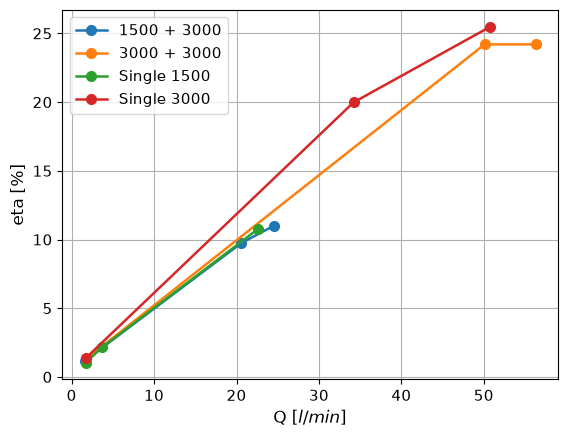

In [4]:
single_eta_15 = np.array([10.76, 2.15, 1.04])
single_eta_30 = np.array([25.49, 19.98, 1.36])
q_3000_exp = np.array([50.8, 34.2, 1.7])
q_1500_exp = np.array([22.6, 3.7, 1.7])

#50/100
Q50 = np.array([24.5, 20.6, 1.6])
eta50 = np.array([10.99, 9.75,1.18])
H50 = np.array([2.3, 2.4, 2.9])

#100/100%
#Data
Q100 = np.array([56.3, 50.1, 1.7])
eta100 = np.array([24.2,24.2,1.28])
H100 = np.array([7.9,8.6,11])

#Theoretical
Qt100 = (Q100/(1000*60))/2

def H_3000_3000(Qt100):
    return 9.81 - 0.7E6*Qt100**2

def H_1500_3000():
    a3000 = 9.81
    b3000 = 2.8E6
    a1500 = 2.714
    b1500 = 3.8E6

    #1500
    H_temp_1500 = np.linspace(0,a1500,10)
    Q_temp_1500 = mth.sqrt((a1500-H_temp_1500)/b1500)        # m^3/s

    #3000
    H_temo_3000 = np.linspace(0,a3000,10)
    Q_temp_3000 = mth.sqrt((a3000 - H_temp_3000)/b3000)

    #Total flow:
    Q_t = Q_temp_1500 + Q_temp_3000


plt.plot(Q50, eta50, label = '1500 + 3000', linestyle = '-', marker = 'o')
plt.plot(Q100, eta100, label = '3000 + 3000', linestyle = '-', marker = 'o')
plt.plot(q_1500_exp, single_eta_15, label = 'Single 1500', linestyle = '-', marker = 'o')
plt.plot(q_3000_exp, single_eta_30, label = 'Single 3000', linestyle = '-', marker = 'o')
plt.xlabel(r'Q [${l/min}$]')
plt.ylabel('eta [%]')
plt.legend()
plt.grid()
plt.show()

0.0012254724916632364 0.0012001017681167988 10.766468863845233 2.81095388879957
3000 RPM Single Pump Equation: H = 10.766 - 0.001*Q^2
1500 RPM Single Pump Equation: H = 2.811 - 0.001*Q^2


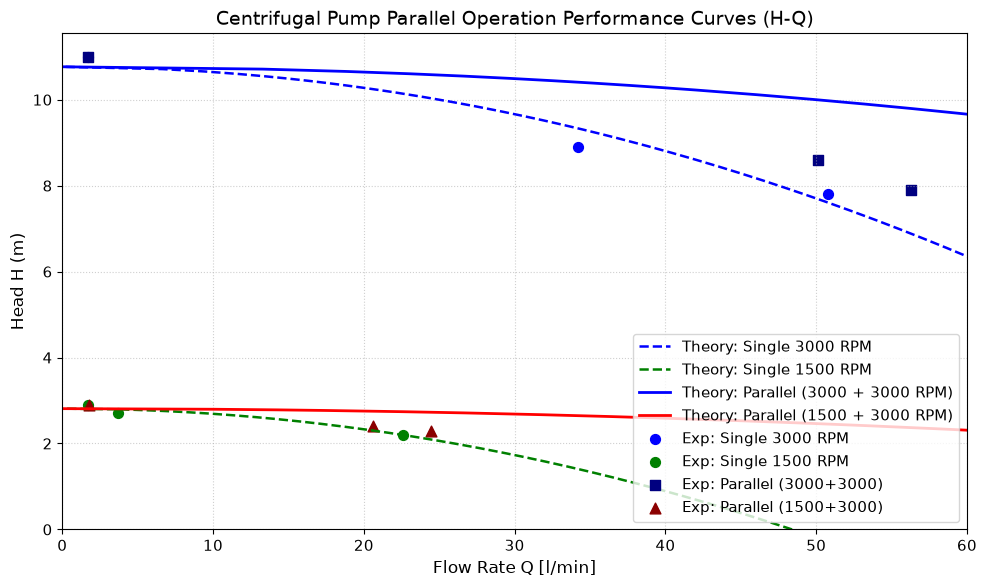

In [5]:
q_3000_exp = np.array([1.7, 34.2, 50.8])  # Replace with your 3000 RPM Q values
h_3000_exp = np.array([11, 8.9, 7.8])# Replace with your 3000 RPM H values
Pm_3000_exp = np.array([236.49,275.65,283.13])

q_1500_exp = np.array([1.7, 3.7, 22.6])  # Replace with your 1500 RPM Q values
h_1500_exp = np.array([2.9, 2.7, 2.2])   # Replace with your 1500 RPM H values

# Parallel Experimental Data (if you have measured points for parallel operation)
q_parallel_full_exp = np.array([1.68, 50.1, 56.28]) # Measured Q for 3000 + 3000 RPM
h_parallel_full_exp = np.array([11.0, 8.6, 7.9])
Pm_parallel_full_exp = np.array([246.06,289.99,299.22])

q_parallel_mixed_exp = np.array([1.8, 20.58, 24.48]) # Measured Q for 1500 + 3000 RPM
h_parallel_mixed_exp = np.array([2.9, 2.4, 2.3])
Pm_parallel_mixed_exp = np.array([74.10,82.72,83.95])

# ==========================================
# 2. CURVE FITTING (H = A - B*Q^2)
# ==========================================
# Fit 3000 RPM: H = A1 - B1 * Q^2
poly_3k = np.polyfit(q_3000_exp**2, h_3000_exp, 1)
B1 = -poly_3k[0]
A1 = poly_3k[1]

# Fit 1500 RPM: H = A2 - B2 * Q^2
poly_15k = np.polyfit(q_1500_exp**2, h_1500_exp, 1)
B2 = -poly_15k[0]
A2 = poly_15k[1]

print(B1,B2,A1,A2)
print(f"3000 RPM Single Pump Equation: H = {A1:.3f} - {B1:.3f}*Q^2")
print(f"1500 RPM Single Pump Equation: H = {A2:.3f} - {B2:.3f}*Q^2")


# ==========================================
# 3. THEORETICAL CALCULATIONS
# ==========================================
# Define Head range from max shut-off head down to zero
h_range1 = np.linspace(0, A1, 200)
h_range2 = np.linspace(0, A2, 200)

# Single Pump Flows at given Head H
q_3000_theory =  np.sqrt((A1 - h_range1) / B1) #np.maximum(0,
q_1500_theory =  np.sqrt((A2 - h_range2) / B2)

# Combined Parallel Flows:
# 1. Full Speed Parallel (3000 + 3000 RPM): Both pumps equal flow
q_parallel_full_theory = 2 * q_3000_theory

# 2. Mixed Speed Parallel (1500 + 3000 RPM): Horizontal sum of individual flows
q_parallel_mixed_theory = q_3000_theory + q_1500_theory


# ==========================================
# 4. PLOTTING PERFORMANCE CURVES
# ==========================================
plt.figure(figsize=(10, 6))

# Theoretical Curves (Lines)
plt.plot(q_3000_theory, h_range1, 'b--', label='Theory: Single 3000 RPM')
plt.plot(q_1500_theory, h_range2, 'g--', label='Theory: Single 1500 RPM')
plt.plot(q_parallel_full_theory, h_range1, 'b-', linewidth=2, label='Theory: Parallel (3000 + 3000 RPM)')
plt.plot(q_parallel_mixed_theory, h_range2, 'r-', linewidth=2, label='Theory: Parallel (1500 + 3000 RPM)')

# Experimental Data Points (Markers)
plt.scatter(q_3000_exp, h_3000_exp, color='blue', marker='o', s=50, label='Exp: Single 3000 RPM')
plt.scatter(q_1500_exp, h_1500_exp, color='green', marker='o', s=50, label='Exp: Single 1500 RPM')
plt.scatter(q_parallel_full_exp, h_parallel_full_exp, color='navy', marker='s', s=60, label='Exp: Parallel (3000+3000)')
plt.scatter(q_parallel_mixed_exp, h_parallel_mixed_exp, color='darkred', marker='^', s=60, label='Exp: Parallel (1500+3000)')

# Formatting Plot
plt.title('Centrifugal Pump Parallel Operation Performance Curves (H-Q)', fontsize=14)
plt.xlabel('Flow Rate Q [l/min]', fontsize=12)
plt.ylabel('Head H (m)', fontsize=12)
plt.xlim(left=0, right=60)
plt.ylim(bottom=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

# Display
plt.show()